# Track 2

## Water Potability dataset  (kaggle.com/datasets/adityakadiwal/water-potability)

### Setup

In [3]:
import warnings, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, brier_score_loss,
                             confusion_matrix, balanced_accuracy_score)

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
N_SPLITS = 5
TEST_SIZE = 0.20
np.random.seed(SEED)

CFG = {
    "seed": SEED,
    "n_splits": N_SPLITS,
    "test_size": TEST_SIZE,
    "scoring": "balanced_accuracy",
    "n_bootstrap": 200,
    "n_yrand": 50,
    "ad_k": 5,
    "ad_percentile": 95,
}

sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

### Load dataset

In [4]:
def load_water_potability(path=None):
    """Loader Water Potability. Contrato: (X: DataFrame, y: Series, meta: dict)."""
    if path is None:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        df = kagglehub.dataset_load(
            KaggleDatasetAdapter.PANDAS,
            "adityakadiwal/water-potability",
            "water_potability.csv",
        )
    else:
        df = pd.read_csv(path)

    target = "Potability"
    y = df[target].astype(int)
    X = df.drop(columns=[target])

    meta = {
        "name": "water_potability",
        "target": target,
        "positive_label": "potable",
        "negative_label": "no potable",
        "feature_names": list(X.columns),
        "n_samples": len(df),
    }
    return X, y, meta


def load_bbb_logbb(path, smiles_col="SMILES", logbb_col="logBB", threshold=0.0):
    """
    Loader B3P2. Espera un CSV con descriptores ya calculados
    (RDKit/Mordred/Jazzy) + columna logBB. Devuelve el mismo contrato.
    """
    df = pd.read_csv(path)
    y = (df[logbb_col] >= threshold).astype(int)
    drop = [c for c in (smiles_col, logbb_col, "ID", "Name") if c in df.columns]
    X = df.drop(columns=drop)
    X = X.select_dtypes(include=[np.number])

    meta = {
        "name": "bbb_logbb",
        "target": logbb_col,
        "positive_label": "BBB+",
        "negative_label": "BBB-",
        "feature_names": list(X.columns),
        "n_samples": len(df),
        "threshold_logbb": threshold,
    }
    return X, y, meta


X, y, META = load_water_potability()
print(META["name"], X.shape, "| balance:", y.value_counts(normalize=True).round(3).to_dict())
X.head()

/home/meli/Documents/Github/hackathon-workshop-main/quantathon/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 513k/513k [00:00<00:00, 1.29MB/s]

water_potability (3276, 9) | balance: {0: 0.61, 1: 0.39}


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075


## EDA

### EDA Missingness

Si las dos columnas de na_by_class difieren mucho, el patrón de ausencia lleva información y conviene agregar indicadores binarios. En agua las tasas salen prácticamente iguales

Filas completas: 61.4%


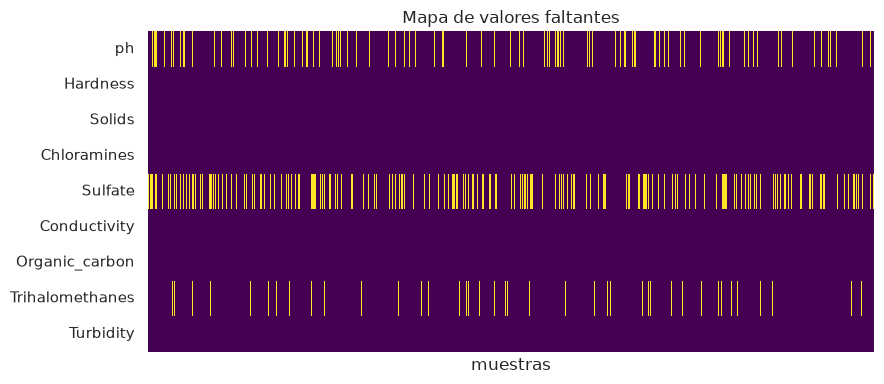

,n_missing,pct
Sulfate,781,23.84
ph,491,14.99
Trihalomethanes,162,4.95
Solids,0,0.00
Hardness,0,0.00
Chloramines,0,0.00
Conductivity,0,0.00
Organic_carbon,0,0.00
Turbidity,0,0.00


,feature,pct_NaN_no potable,pct_NaN_potable
0,ph,15.72,13.85
1,Sulfate,24.42,22.93
2,Trihalomethanes,5.36,4.30


In [5]:
def eda_missingness(X, y, meta):
    na = X.isna().sum()
    na_tbl = pd.DataFrame({
        "n_missing": na,
        "pct": (na / len(X) * 100).round(2),
    }).sort_values("n_missing", ascending=False)

    # ¿el missingness es informativo? tasa de NaN por clase
    rows = []
    for c in X.columns[na > 0]:
        m = X[c].isna()
        rows.append({
            "feature": c,
            f"pct_NaN_{meta['negative_label']}": round(m[y == 0].mean() * 100, 2),
            f"pct_NaN_{meta['positive_label']}": round(m[y == 1].mean() * 100, 2),
        })
    by_class = pd.DataFrame(rows)

    frac_complete = X.dropna().shape[0] / len(X)
    print(f"Filas completas: {frac_complete:.1%}")

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(X.isna().T, cbar=False, ax=ax, cmap="viridis")
    ax.set_title("Mapa de valores faltantes")
    ax.set_xlabel("muestras"); ax.set_xticks([])
    plt.tight_layout(); plt.savefig("figures/missingness.png", dpi=150); plt.show()

    return na_tbl, by_class

na_tbl, na_by_class = eda_missingness(X, y, META)
display(na_tbl)
display(na_by_class)

### EDA: distribuciones y solapamiento por clase

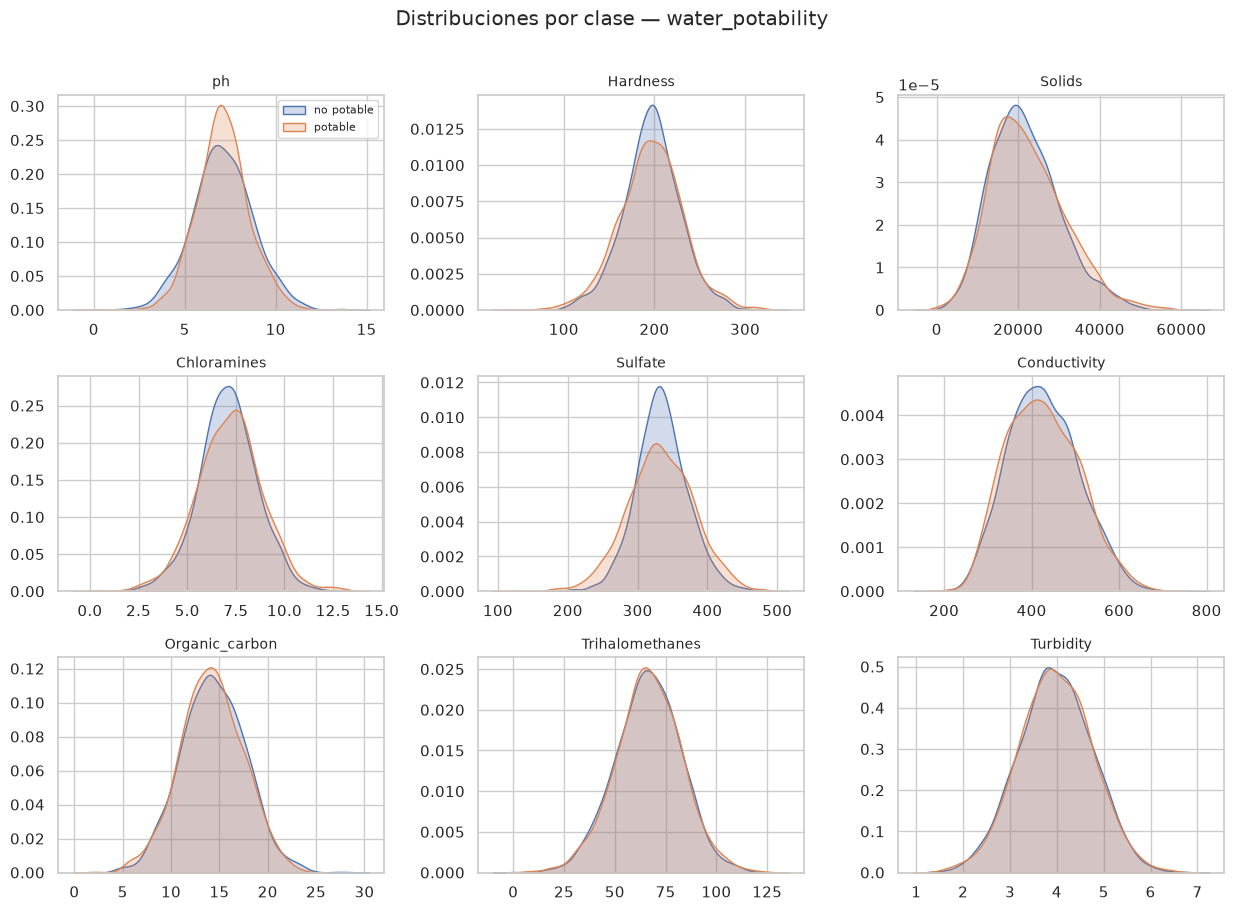

In [6]:
def eda_distributions(X, y, meta, max_features=12):
    cols = list(X.columns)[:max_features]
    n = len(cols)
    ncol = 3
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow))
    axes = np.atleast_1d(axes).ravel()

    for ax, c in zip(axes, cols):
        for cls, lab in [(0, meta["negative_label"]), (1, meta["positive_label"])]:
            sns.kdeplot(X.loc[y == cls, c].dropna(), ax=ax, label=lab, fill=True, alpha=.25)
        ax.set_title(c, fontsize=10)
        ax.set_xlabel(""); ax.set_ylabel("")
    for ax in axes[n:]:
        ax.axis("off")
    axes[0].legend(fontsize=8)
    plt.suptitle(f"Distribuciones por clase — {meta['name']}", y=1.01)
    plt.tight_layout(); plt.savefig("figures/distributions.png", dpi=150); plt.show()

eda_distributions(X, y, META)

EDA: correlaciones y señal disponible

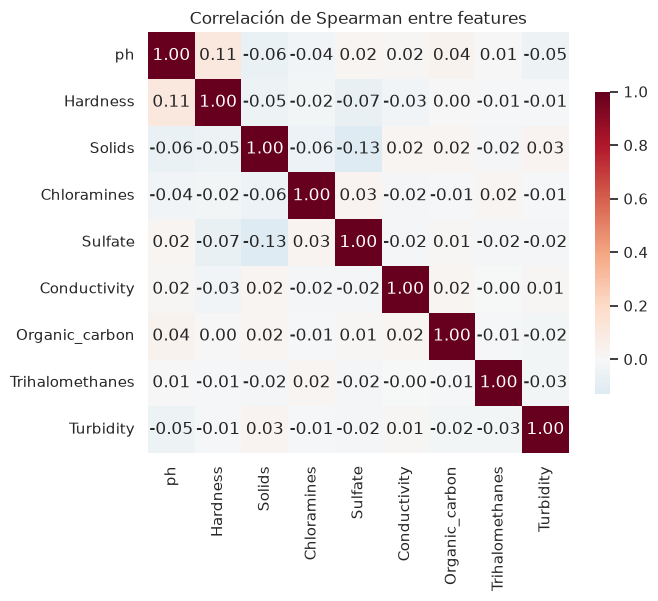

,spearman_vs_target,mutual_info,abs_corr
Organic_carbon,-0.0268,0.0040,0.0268
Solids,0.0262,0.0011,0.0262
Chloramines,0.0250,0.0000,0.0250
Sulfate,-0.0142,0.0024,0.0142
Hardness,-0.0106,0.0266,0.0106
Conductivity,-0.0104,0.0071,0.0104
Trihalomethanes,0.0053,0.0000,0.0053
ph,-0.0016,0.0002,0.0016
Turbidity,0.0011,0.0031,0.0011


In [7]:
from sklearn.feature_selection import mutual_info_classif

def eda_signal(X, y, meta):
    Xi = X.fillna(X.median())

    corr = Xi.corr(method="spearman")
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, annot=len(corr) <= 12, fmt=".2f", cmap="RdBu_r",
                center=0, square=True, ax=ax, cbar_kws={"shrink": .7})
    ax.set_title("Correlación de Spearman entre features")
    plt.tight_layout(); plt.savefig("figures/corr_features.png", dpi=150); plt.show()

    tgt = pd.Series(
        {c: pd.Series(Xi[c]).corr(y, method="spearman") for c in Xi.columns},
        name="spearman_vs_target",
    )
    mi = pd.Series(
        mutual_info_classif(Xi, y, random_state=CFG["seed"]),
        index=Xi.columns, name="mutual_info",
    )
    tbl = pd.concat([tgt, mi], axis=1)
    tbl["abs_corr"] = tbl["spearman_vs_target"].abs()
    return tbl.sort_values("abs_corr", ascending=False).round(4)

signal_tbl = eda_signal(X, y, META)
display(signal_tbl)

### PCA y outliers

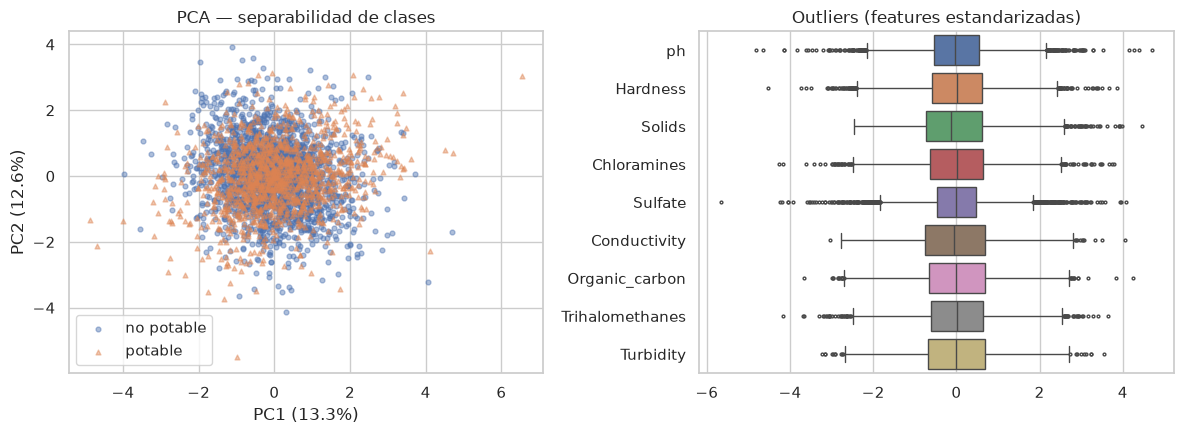

Varianza explicada acumulada (2 PC): 0.26


In [8]:
from sklearn.decomposition import PCA

def eda_separability(X, y, meta):
    Z = StandardScaler().fit_transform(X.fillna(X.median()))
    pca = PCA(n_components=2, random_state=CFG["seed"]).fit(Z)
    P = pca.transform(Z)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for cls, lab, mk in [(0, meta["negative_label"], "o"), (1, meta["positive_label"], "^")]:
        axes[0].scatter(P[y == cls, 0], P[y == cls, 1], s=12, alpha=.45, label=lab, marker=mk)
    axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    axes[0].set_title("PCA — separabilidad de clases"); axes[0].legend()

    Zdf = pd.DataFrame(Z, columns=X.columns)
    sns.boxplot(data=Zdf, orient="h", ax=axes[1], fliersize=2)
    axes[1].set_title("Outliers (features estandarizadas)")

    plt.tight_layout(); plt.savefig("figures/separability.png", dpi=150); plt.show()
    return pca.explained_variance_ratio_

evr = eda_separability(X, y, META)
print("Varianza explicada acumulada (2 PC):", evr.sum().round(3))

## Preprocesado
### Split estratificado

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CFG["test_size"], stratify=y, random_state=CFG["seed"]
)
print(f"train={X_train.shape}  test={X_test.shape}")
print("balance train:", y_train.value_counts(normalize=True).round(3).to_dict())


def make_preprocessor(enable_feature_filter=False, corr_threshold=0.90, vif_threshold=5.0):
    """
    Agua: enable_feature_filter=False (9 features, no hace falta).
    B3P2: True (1327 descriptores → ~45).
    El filtrado se ajusta SOLO con datos de train (dentro de cada fold de CV).
    """
    steps = [("imp", SimpleImputer(strategy="median")),
             ("sc", StandardScaler())]
    if enable_feature_filter:
        from sklearn.feature_selection import VarianceThreshold
        steps.insert(1, ("var", VarianceThreshold(threshold=0.0)))
        steps.append(("corr", CorrelationPruner(threshold=corr_threshold)))
        steps.append(("vif", VIFPruner(threshold=vif_threshold)))
    return Pipeline(steps)

PREP_KWARGS = dict(enable_feature_filter=False)   # cambiar a True para B3P2

train=(2620, 9)  test=(656, 9)
balance train: {0: 0.61, 1: 0.39}


### Transformers de filtrado (solo necesarios para B3P2)

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationPruner(BaseEstimator, TransformerMixin):
    """Elimina features con |Pearson| > threshold (triángulo superior)."""
    def __init__(self, threshold=0.90):
        self.threshold = threshold

    def fit(self, X, y=None):
        Xd = pd.DataFrame(X)
        corr = Xd.corr().abs().values
        upper = np.triu(corr, k=1)
        drop = set()
        for j in range(upper.shape[1]):
            if any(upper[i, j] > self.threshold for i in range(j)):
                drop.add(j)
        self.keep_idx_ = [i for i in range(Xd.shape[1]) if i not in drop]
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.keep_idx_]


class VIFPruner(BaseEstimator, TransformerMixin):
    """Elimina iterativamente la feature de mayor VIF hasta que todas ≤ threshold."""
    def __init__(self, threshold=5.0, max_iter=200):
        self.threshold = threshold
        self.max_iter = max_iter

    @staticmethod
    def _vif(A):
        # VIF_j = 1 / (1 - R²_j) vía inversa de la matriz de correlación
        C = np.corrcoef(A, rowvar=False)
        C += np.eye(C.shape[0]) * 1e-8
        return np.diag(np.linalg.pinv(C))

    def fit(self, X, y=None):
        A = np.asarray(X, dtype=float)
        keep = list(range(A.shape[1]))
        for _ in range(self.max_iter):
            if len(keep) <= 1:
                break
            v = self._vif(A[:, keep])
            worst = int(np.argmax(v))
            if v[worst] <= self.threshold:
                break
            keep.pop(worst)
        self.keep_idx_ = keep
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.keep_idx_]

## Modelos y Grids

´SVM_RBF´ con ese grid es literalmente la baseline que exige el enunciado del Track 2, y a la vez uno de los cuatro modelos del paper.

In [11]:
def get_model_registry(seed=SEED, use_xgb=True):
    reg = {
        "RL": (
            LogisticRegression(max_iter=5000, class_weight="balanced", random_state=seed),
            {"clf__C": [0.01, 0.1, 1, 10]},
        ),
        "SVM_RBF": (
            SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=seed),
            {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", "auto", 0.01]},
        ),
        "RF": (
            RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=seed),
            {"clf__n_estimators": [300, 600],
             "clf__max_depth": [None, 8, 16],
             "clf__min_samples_leaf": [1, 3]},
        ),
    }
    if use_xgb:
        try:
            from xgboost import XGBClassifier
            reg["XGB"] = (
                XGBClassifier(eval_metric="logloss", tree_method="hist",
                              n_jobs=-1, random_state=seed),
                {"clf__max_depth": [3, 5, 7],
                 "clf__learning_rate": [0.05, 0.1],
                 "clf__n_estimators": [300, 600],
                 "clf__subsample": [0.8, 1.0]},
            )
        except ImportError:
            print("xgboost no instalado — se omite (pip install xgboost)")
    return reg

REGISTRY = get_model_registry()
print(list(REGISTRY))

xgboost no instalado — se omite (pip install xgboost)
['RL', 'SVM_RBF', 'RF']


## Entrenamiento

In [12]:
def fit_all_models(X_train, y_train, registry, prep_kwargs, cfg=CFG):
    cv = StratifiedKFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
    fitted, cv_rows = {}, []

    for name, (estimator, grid) in registry.items():
        pipe = Pipeline([("prep", make_preprocessor(**prep_kwargs)), ("clf", estimator)])
        gs = GridSearchCV(pipe, grid, scoring=cfg["scoring"], cv=cv,
                          n_jobs=-1, refit=True, return_train_score=False)
        gs.fit(X_train, y_train)
        fitted[name] = gs.best_estimator_
        cv_rows.append({
            "model": name,
            "cv_best_BA": round(gs.best_score_, 4),
            "cv_std": round(gs.cv_results_["std_test_score"][gs.best_index_], 4),
            "best_params": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()},
        })
        print(f"{name:8s} CV {cfg['scoring']} = {gs.best_score_:.4f} ± "
              f"{gs.cv_results_['std_test_score'][gs.best_index_]:.4f}")

    return fitted, pd.DataFrame(cv_rows)

FITTED, cv_table = fit_all_models(X_train, y_train, REGISTRY, PREP_KWARGS)
display(cv_table)

RL       CV balanced_accuracy = 0.4901 ± 0.0206


/home/meli/Documents/Github/hackathon-workshop-main/quantathon/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/meli/Documents/Github/hackathon-workshop-main/quantathon/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/meli/Documents/Github/hackathon-workshop-main/quantathon/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/meli/Documents/Github/

SVM_RBF  CV balanced_accuracy = 0.6492 ± 0.0196
RF       CV balanced_accuracy = 0.6417 ± 0.0141


,model,cv_best_BA,cv_std,best_params
0,RL,0.4901,0.0206,{'C': 0.01}
1,SVM_RBF,0.6492,0.0196,"{'C': 1, 'gamma': 'scale'}"
2,RF,0.6417,0.0141,"{'max_depth': 16, 'min_samples_leaf': 3, 'n_es..."


## Evaluación

In [13]:
def compute_metrics(y_true, proba, tau=0.5):
    y_pred = (proba >= tau).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "brier": brier_score_loss(y_true, proba),
    }


def choose_tau(model, X_train, y_train, cfg=CFG, grid=np.arange(0.20, 0.81, 0.01)):
    """τ óptimo por CV sobre TRAIN. Se congela antes de tocar test."""
    cv = StratifiedKFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
    oof = np.zeros(len(y_train))
    Xa, ya = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
    for tr, va in cv.split(Xa, ya):
        from sklearn.base import clone
        m = clone(model).fit(Xa.iloc[tr], ya.iloc[tr])
        oof[va] = m.predict_proba(Xa.iloc[va])[:, 1]
    scores = [(t, f1_score(ya, (oof >= t).astype(int), zero_division=0)) for t in grid]
    return float(max(scores, key=lambda s: s[1])[0])


def evaluate_all(fitted, X_train, y_train, X_test, y_test, tau=None):
    rows, taus, cms = [], {}, {}
    for name, model in fitted.items():
        t = tau if tau is not None else choose_tau(model, X_train, y_train)
        taus[name] = t
        for split, Xs, ys in [("train", X_train, y_train), ("test", X_test, y_test)]:
            p = model.predict_proba(Xs)[:, 1]
            m = compute_metrics(ys, p, tau=t)
            m.update({"model": name, "split": split, "tau": round(t, 3)})
            rows.append(m)
            if split == "test":
                cms[name] = confusion_matrix(ys, (p >= t).astype(int))
    cols = ["model", "split", "tau", "accuracy", "balanced_accuracy",
            "precision", "recall", "f1", "roc_auc", "brier"]
    return pd.DataFrame(rows)[cols].round(4), taus, cms

# Para B3P2: pasar tau=0.40 y así replicar el paper exactamente.
results, TAUS, CMS = evaluate_all(FITTED, X_train, y_train, X_test, y_test, tau=None)
results.to_csv("results/metrics_main.csv", index=False)
display(results[results.split == "test"].sort_values("f1", ascending=False))

/home/meli/Documents/Github/hackathon-workshop-main/quantathon/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/meli/Documents/Github/hackathon-workshop-main/quantathon/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/meli/Documents/Github/hackathon-workshop-main/quantathon/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/meli/Documents/Github/

,model,split,tau,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,brier
1,RL,test,0.43,0.3902,0.5000,0.3902,1.0000,0.5614,0.5488,0.2489
5,RF,test,0.43,0.5732,0.5923,0.4677,0.6797,0.5541,0.6712,0.2185
3,SVM_RBF,test,0.31,0.5366,0.5652,0.4406,0.6953,0.5394,0.6440,0.2217


### Matriz de confusión

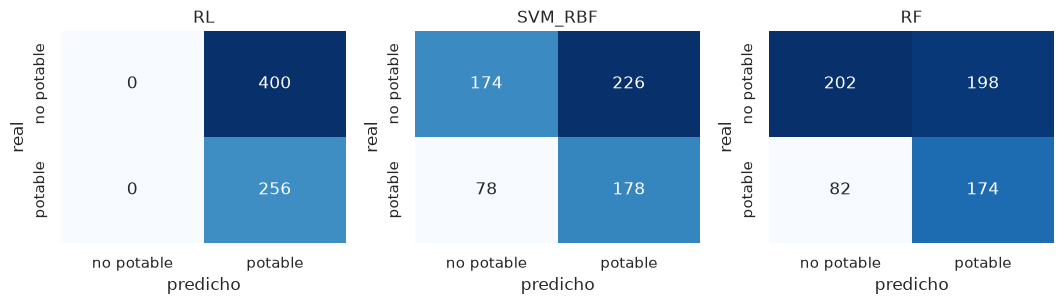

In [14]:
def plot_confusions(cms, meta):
    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.2))
    axes = np.atleast_1d(axes)
    labels = [meta["negative_label"], meta["positive_label"]]
    for ax, (name, cm) in zip(axes, cms.items()):
        sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
                    xticklabels=labels, yticklabels=labels)
        ax.set_title(name); ax.set_xlabel("predicho"); ax.set_ylabel("real")
    plt.tight_layout(); plt.savefig("figures/confusion_matrices.png", dpi=150); plt.show()

plot_confusions(CMS, META)